# Notebook \#6: Machine Teaching for XAI
#### by Sebastian Einar Salas Røkholt

---


**Index**  
- [**1 - Introduction and Setup**](#1---introduction-and-setup)  
  - [*1.1 Setup*](#11-setup)  
  - [*1.2 Load the Anomaly Detection Model*](#12-load-the-model)  
  - [*1.3 Data Preparation*](#13-data-preparation)  
- [**2 - Chapter 2**](#2---chapter-2)  
  - [*2.1 ....*](#21-....)  

---

**References & Background Literature:**
- [Optimal Robust Simplifications for Explaining Time Series Classifications](https://xai.w.uib.no/files/2024/07/ORS.pdf) (2024) by Telle, Ferri & Håvardstun.
- [XAI with Machine Teaching when Humans Are (Not) Informed about the Irrelevant Features](https://doi.org/10.1007/978-3-031-43418-1_23) (2023) by Håvardstun, Ferri, Hernández-Orallo, Parviainen & Telle. 
- [When Redundancy Matters: Machine Teaching of Representations](https://arxiv.org/pdf/2401.12711.pdf) (2024) by Ferri, Garigliotti, Håvardstun, Hernandez-Orallo & Telle.
- [XAI with Machine Teaching when Humans Are (Not) Informed about the Irrelevant Features](https://doi.org/10.1007/978-3-031-43418-1_23) (2023) by Håvardstun, Ferri, Hernandez-Orallo, Parviainen & Telle. 


## 1 - Introduction and Setup
The aim of this notebook is to build a suitable teaching set which can be used to serve example-based explanations of the anomaly detection system (the black box AI) to human users. 

This notebook uses a class-based API defined in the `mt4xai` package's `teach` and `data` modules: 
- `TeachingPool` owns the pool (`pool.parquet`), binning, and paths.
- `TeachingSet` performs selection with greedy facility-location (+ lazy pruning), then exposes A/B/C samplers.
- `ChargingSession` contains the original, dense, unscaled arrays for the `power` series (and optionally for other channels/features as well). 
- `ChargingSessionSimplification` with knots\* only (indices + values). We cnvert these to dense simplifications and fetch original raw series on demand.
A *knot* is an endpoint of a straight line segment in the simplification. We define **k = number of straight line segments = knots − 1**.

In [ ]:
import sys
import torch
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# project config
sys.path.append(str(Path.cwd().parent))  # Add scripts (e.g. project_config.py) in parent dir to path
from project_config import load_config
cfg = load_config()

# Modules from the project's MT4XAI package
%load_ext autoreload
%autoreload 2
from mt4xai.model import load_lstm_model
from mt4xai.data import split_data, apply_scalers, fit_scalers_on_train, build_loader
from mt4xai.ors import ORSParams
from mt4xai.teach import TeachingPool, TeachingPoolConfig, TeachingSet, selection_vs_pool_report

# Pandas config
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 120)

# paths
DATA_FP = cfg.paths.dataset
MODEL_FP = cfg.paths.final_model
TEACHING_DIR = Path(cfg.paths.teaching_pool) 
POOL_PARQUET = TEACHING_DIR / "pool.parquet"
SAMPLE_PLAN = TEACHING_DIR / "sampled_normals.json"

# constants / tunable knobs
DEVICE = torch.device(cfg.project.device)
print("Device: ", DEVICE)
RANDOM_SEED = cfg.project.random_seed
AD_THRESHOLD = cfg.anomaly_detection.rmse_threshold

CONFIG FILE LOADED: 
{'project': {'random_seed': 42, 'root_dir': None}, 'paths': {'dataset': 'Data/etron55-charging-sessions.parquet', 'teaching_pool': 'Data/teaching_pool', 'models': 'Models', 'final_model': 'Models/final/final_model.pth', 'figures': 'Figures', 'logs': 'Logs'}, 'inference': {'horizon': 5, 'final_model_name': 'final_model.pth', 'power_weight': 0.6522982410461, 'horizon_decay_lambda': 0.4}, 'anomaly_detection': {'t_min_eval': 1, 'rmse_threshold': 8.5962, 'ad_pct_threshold': 0.95, 'metric': 'macro_rmse'}, 'ors': {'soc_stage1_mode': 'rdp', 'soc_rdp_epsilon': 0.75, 'soc_rdp_candidates': 5, 'soc_rdp_eps_min': 1e-06, 'soc_rdp_eps_max': 100.0, 'stage2_err_metric': 'l2', 'epsilon_mode': 'fraction'}, 'teaching': {'teaching_pool_dir': '../Data/teaching_pool', 'teaching_set_size': 200}}
Device:  cuda


### 1.2 Load the Forecasting Model

In [2]:
# load model and hyperparams from Ray Tune checkpoint
model, ckpt = load_lstm_model(MODEL_FP, device=DEVICE)
input_features  = ckpt["input_features"]
target_features = ckpt["target_features"]
H = int(ckpt["config"]["horizon"])  # forecast horizon
idx_power_inp = input_features.index("power")
idx_soc_inp = input_features.index("soc")
print(f"Loaded pretrained forecasting model {model}")

/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/src/mt4xai/model.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

Loaded pretrained forecasting model MultiHorizonLSTM(
  (lstm): LSTM(12, 512, num_layers=5, batch_first=True, dropout=0.2754636459029)
  (linear): Linear(in_features=512, out_features=10, bias=True)
)


### 1.3 Data Preparation
In this section, we will load, transform, and split the data in exactly the same way as we did previously in order to extract the test set, which we will use as a starting point for building the teaching set $S$. 

In [3]:
# load and scale data (in the same way as in previous notebooks)
df = pd.read_parquet(DATA_FP)
drop_cols = [c for c in [
    "energy","charger_category","timestamp","nearest_weather_station",
    "timestamp_d","lat","lon","timestamp_H"
] if c in df.columns]
df = df.drop(columns=drop_cols).copy()

train_df, val_df, test_df = split_data(df, test_size=0.2, validation_size=0.1, random_seed=RANDOM_SEED)  # exact same split as before
scalers = fit_scalers_on_train(train_df, list(set(input_features) | set(target_features)))
power_scaler, soc_scaler = scalers["power"], scalers["soc"]
test_s = apply_scalers(test_df, scalers)

test_loader = build_loader(test_s, input_features, target_features, H,
                           batch_size=16, shuffle=False, num_workers=0)
print(f"There are {len(test_loader.dataset.groups)} charging sessions in the test set")

There are 12183 charging sessions in the test set


### 2 - Computing the Teaching Pool
The Teaching Pool is a relatively large collection of samples (charging sessions / examples) from the test set. 

#### 2.1 - Running the pool constructor
Constructing the pool of simplifications + raw sessions is very computationally intensive, since ORS runs model inference thousands of times per simplification, and we want over a thousand simplifications in our teaching pool. The `mt4xai` API let's us load an existing pool (from the file `pool.parquet`) or construct it from scratch. Construction runs inference + ORS + embedding and writes the SQLite cache and the Parquet snapshot.


In [4]:
# choose: load an existing pool if available; otherwise show how to construct
pool_parquet = TEACHING_DIR / "pool.parquet"

if pool_parquet.exists():
    # loads the pool snapshot from disk
    print("Loaded previously computed teaching pool from disk")
    pool = TeachingPool.load_from_parquet(pool_parquet)
else:
    # builds the pool end-to-end, then loads it
    # builds the pool of simplifications and raw sessions
    tpconfig = TeachingPoolConfig(
        model_path=MODEL_FP,  # our pre-trained "black box" (multivariate LSTM) model
        output_dir=TEACHING_DIR,
        threshold=AD_THRESHOLD,  # 8.5962, e.g the 95th percentile
        seed=RANDOM_SEED,
        device=DEVICE,
        export_every=25,
        L=128, P=4,   # for embeddings 
        ors_params=ORSParams(
            stage1_mode="dp_prefix", stage2_err_metric="l2",
            dp_q=200, rdp_stage1_candidates=30,
            dp_alpha=0.01, beta=3.0, gamma=0.05,
            R=3000, epsilon_mode="fraction", epsilon_value=0.2,
            t_min_eval=1, min_k=1, max_k=12, seed=RANDOM_SEED,
            soc_stage1_mode="rdp", soc_rdp_epsilon=0.75,
            model_id="final_model.pth"
        ),
        power_weight=cfg.inference.power_weight, 
        decay_lambda=cfg.inference.horizon_decay_lambda
    )

    pool = TeachingPool.construct(
        model=model,
        config=tpconfig,
        test_loader=test_loader,
        power_scaler=power_scaler,
        soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp,
        idx_soc_inp=idx_soc_inp,
    )

Loaded previously computed teaching pool from disk


#### 2.2 - Teaching pool summary statistics

In [5]:
# Summary statistics
pool.describe()
display(pool.pool_df.head())
print("Frequencies of k for normal sessions in the teaching pool:")
print(pool.pool_df[pool.pool_df["label_text"] == "normal"]["k"].value_counts())
print("Frequencies of k for abnormal sessions in the teaching pool:")
print(pool.pool_df[pool.pool_df["label_text"] == "abnormal"]["k"].value_counts())

[teaching pool] rows=1172, classes:
label_int
0    586
1    586

[k] stats:
 count    1172.000000
mean        3.537543
std         1.751259
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        12.000000


,session_id,label_text,label_int,k,err,frag,robust_prob,margin,threshold,model_id,ts_unix,sts_full_path,piv_path,emb_dim,emb,raw_power_path,raw_soc_path,piv_soc_path,sts_soc_path
0,137598,normal,0,2.0,0.300746,0.000000,1.000000,8.295454,8.5962,final_model.pth,1.761166e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/137...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/137598.npy,264,"[2.240215301513672, 2.1924808025360107, 2.1447460651397705, 2.0970146656036377, 2.0492897033691406, 2.00156450271606...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/13...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/1375...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/1375...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/1375...
1,167874,abnormal,1,4.0,13.030439,0.000000,1.000000,4.434239,8.5962,final_model.pth,1.761166e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/167...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/167874.npy,264,"[-2.2508716583251953, -1.8199647665023804, -1.3890577554702759, -0.9581508040428162, -0.5272438526153564, -0.0963368...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/16...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/1678...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/1678...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/1678...
2,231570,abnormal,1,4.0,9.624545,0.041333,0.958667,1.028345,8.5962,final_model.pth,1.761166e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/231...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/231570.npy,264,"[-2.075390100479126, -1.734521746635437, -1.3936532735824585, -1.0527849197387695, -0.711916446685791, -0.3710480034...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/23...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/2315...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/2315...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/2315...
3,240316,normal,0,3.0,1.925004,0.035667,0.964333,6.671196,8.5962,final_model.pth,1.761167e+09,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/240...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/240316.npy,264,"[1.6217665672302246, 1.6354061365127563, 1.6490458250045776, 1.6626853942871094, 1.6763250827789307, 1.6899646520614...",/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/24...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/2403...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/2403...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/2403...
4,248477,abnormal,1,4.0,8.747483,0.250333,0.749667,0.151283,

Frequencies of k for normal sessions in the teaching pool:
k
2.0    381
3.0     99
4.0     60
1.0     24
5.0     20
6.0      2
Name: count, dtype: int64
Frequencies of k for abnormal sessions in the teaching pool:
k
3.0     176
4.0     129
5.0     116
6.0      85
7.0      30
8.0      19
2.0      12
9.0       9
11.0      4
12.0      3
10.0      3
Name: count, dtype: int64


#### 2.3 - Binning the pool by class and $k$
We bin by `(class_label, k)` to form strata used by selection.  
Binning may be **quantile** (robust) or **fixed** (stable edges). We keep the earlier defaults.

Outputs:
- `pool.bins_df` with `k_bin_idx` and `k_bin_label`
- a JSON meta on disk with edges and counts (for provenance)

In [6]:
# bins the pool by k and class
bins_df, bins_meta = pool.bin_pool(
    label_source="base", # use base labels from the sampling plan
    binning="fixed",   # "fixed" is stable across runs, while "quantile" adapts to the distribution
    target_bins=5, min_bins=4, max_bins=6,
    fixed_edges_per_class=None,  # None => auto edges from observed [k_min, k_max]
    ensure_extrema=True, save_outputs=True,
    verbose=True
)

rows in pool: 1172
class 0:
  unique k: 6  range: [1,6]
  k counts: {1: 24, 2: 381, 3: 99, 4: 60, 5: 20, 6: 2}
  bins (5): labels=[1, 2, 3, 4, 5, 6]  counts=[405, 99, 60, 20, 2]
class 1:
  unique k: 11  range: [2,12]
  k counts: {2: 12, 3: 176, 4: 129, 5: 116, 6: 85, 7: 30, 8: 19, 9: 9, 10: 3, 11: 4, 12: 3}
  bins (5): labels=[2, 4, 6, 8, 10, 12]  counts=[317, 201, 49, 12, 7]


### 3 - Constructing the teaching set $S$
In this section, we select diverse examples from the teaching pool to construct our teaching set $S$. </br>
We employ a teaching set construction strategy proposed by ...

#### 3.1 - Selection budget
We now derive per-bin budgets for the selector.  
Two policies are supported:
- even: split the per-class target evenly across that class’s bins; remainders go to densest bins.
- proportional: split by per-bin availability; fix rounding drift.

We stick with **even** for clarity.

In [7]:
# derives a per-bin budget (target ≤100 per class)
per_bin_budget = pool.derive_per_bin_budget(per_class_target=100, bin_allocation="even")

print("budgets (class 0):", per_bin_budget.get("0", {}))
print("budgets (class 1):", per_bin_budget.get("1", {}))

budgets (class 0): {'[1, 2]': 20, '[2, 3]': 20, '[3, 4]': 20, '[4, 5]': 20, '[5, 6]': 20}
budgets (class 1): {'[2, 4]': 20, '[4, 6]': 20, '[6, 8]': 20, '[8, 10]': 20, '[10, 12]': 20}


#### 3.2 - Teaching set selection

We construct a `TeachingSet` from the $k$ strata and budgets. The objective is:

$$
F(S) = \sum_{i \in U} \max_{s \in S} \mathrm{sim}(i,s) \\
\qquad\mathrm{sim} = \text{cosine}(\text{L2-normalised embeddings})
$$

At each step, we take the argmax of the **marginal gain** plus small linear terms:

$$
\mathrm{score}(x) = \Delta F(x \mid S) + \lambda_m\,\mathrm{margin}(x) + \lambda_r\,\mathrm{robust\_prob}(x)\\
\quad (\lambda_m=0.10, \lambda_r=0.05)
$$

We also add the *deterministic* lever: `min_per_k=1` inside each bin to ensure rare `k` values are represented.


In [8]:
# runs the selection process
s = TeachingSet(
    pool,
    per_bin_budget=per_bin_budget,
    per_class_target=None,   # used only if per_bin_budget=None
    bin_allocation="even",
    lambda_margin=0.10,
    lambda_robust=0.05,
    normalize_embeddings=True,
    lazy_prune=True,
    dtw_tie_refine=False, # keep off unless near ties are common
    sim_clip_min=0.0,  # clip negatives to 0 for safer gains
    seed=RANDOM_SEED,
    min_per_k=2,  # easy lever: guarantee ≥2 per k inside each bin (if present)
    output_dir=TEACHING_DIR,
)

s.save(output_dir=TEACHING_DIR)

[teach] selection complete.
  class 0: selected=55 | F(S)=573.0051
  class 1: selected=54 | F(S)=501.4734
  wrote → /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/selection.parquet
  wrote → /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/selection_config.json


#### 3.3 - Teaching set analytics

In [9]:
s.describe()
display(s.teaching_set_df.head())

[teaching set] rows=109, classes:
class_label
0    55
1    54

[coverage] facility-location by class:
  class 0: 573.0051
  class 1: 501.4734

[per-bin selected] counts by class:
  class 0: {'[1, 2]': 20, '[2, 3]': 20, '[3, 4]': 2, '[4, 5]': 11, '[5, 6]': 2}
  class 1: {'[2, 4]': 20, '[4, 6]': 20, '[6, 8]': 0, '[8, 10]': 8, '[10, 12]': 6}


,session_id,class_label,k,k_bin_idx,k_bin_label,label_int,label_text,robust_prob,margin,threshold,...,raw_soc_path,sts_soc_path,piv_soc_path,model_id,gain_coverage,score_total,rank_in_bin,rank_in_class,k_bin,chosen_neighbors
0,8661544,0,2,0,"[1, 2]",0,normal,1.000,8.363038,8.5962,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/8661...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/8661...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/8661...,final_model.pth,191.079895,191.966199,1,1,"[1, 2]","[8661544, 6356776, 1517248, 2617274, 2045529]"
1,10706141,0,2,0,"[1, 2]",0,normal,1.000,8.221996,8.5962,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/1070...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/1070...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/1070...,final_model.pth,1.218426,2.090626,2,2,"[1, 2]","[10706141, 6413520, 5813334, 2617274, 6356776]"
2,12145955,0,1,0,"[1, 2]",0,normal,1.000,8.407482,8.5962,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/1214...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/1214...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/1214...,final_model.pth,6.536997,7.427745,3,3,"[1, 2]","[12145955, 10229995, 2560674, 2361727, 9489647]"
3,9189528,0,1,0,"[1, 2]",0,normal,1.000,8.387293,8.5962,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/9189...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/9189...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/9189...,final_model.pth,0.000012,0.888741,4,4,"[1, 2]","[12145955, 10229995, 2560674, 2361727, 9489647]"
4,4275867,0,2,0,"[1, 2]",0,normal,0.989,5.802258,8.5962,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/4275...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/4275...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/4275...,final_model.pth,157.401123,158.030799,5,5,"[1, 2]","[4275867, 2368429, 2537218, 6174344, 8743262]"


What are the k values for selected examples vs the examples in the pool? </br>

We compare `(class, k)` and `(class, k-bin)` frequencies to inspect representation, especially at the tails. </br>
We report **selection rate** and **representation lift**:

$$
\text{selection\_rate} = \frac{n_{\text{sel}}}{n_{\text{pool}}},\quad
\text{lift} = \frac{\text{share}_{\text{sel}}}{\text{share}_{\text{pool}}}
$$

Per-class, per-k comparison:


,class_label,k,n_pool,share_in_class_pool,n_sel,share_in_class_sel,selection_rate,lift
0,0,1,24,0.040956,2.0,0.036364,0.083,0.888
1,0,2,381,0.650171,18.0,0.327273,0.047,0.503
2,0,3,99,0.168942,20.0,0.363636,0.202,2.152
3,0,4,60,0.102389,2.0,0.036364,0.033,0.355
4,0,5,20,0.03413,11.0,0.200000,0.55,5.86
5,0,6,2,0.003413,2.0,0.036364,1.0,10.655
6,1,2,12,0.020478,3.0,0.055556,0.25,2.713
7,1,3,176,0.300341,13.0,0.240741,0.074,0.802
8,1,4,129,0.220137,4.0,0.074074,0.031,0.336
9,1,5,116,0.197952,15.0,0.277778,0.129,1.403



Per-class, per-k-bin comparison:


,class_label,k_bin_label,n_pool,share_in_class_pool,n_sel,share_in_class_sel,selection_rate,lift
0,0,"[1, 2]",405,0.691126,20.0,0.363636,0.049,0.526
1,0,"[2, 3]",99,0.168942,20.0,0.363636,0.202,2.152
2,0,"[3, 4]",60,0.102389,2.0,0.036364,0.033,0.355
3,0,"[4, 5]",20,0.03413,11.0,0.200000,0.55,5.86
4,0,"[5, 6]",2,0.003413,2.0,0.036364,1.0,10.655
5,1,"[10, 12]",7,0.011945,6.0,0.111111,0.857,9.302
6,1,"[2, 4]",317,0.540956,20.0,0.370370,0.063,0.685
7,1,"[4, 6]",201,0.343003,20.0,0.370370,0.1,1.08
8,1,"[6, 8]",49,0.083618,0.0,0.000000,0.0,0.0
9,1,"[8, 10]",12,0.020478,8.0,0.148148,0.667,7.235



Extremes summary: (min/max k and rarest k per class in the pool)


,class_label,min_k,max_k,rare_k
0,0,1.0,6.0,6.0
1,1,2.0,12.0,10.0



Teaching Pool share vs Teaching Set share


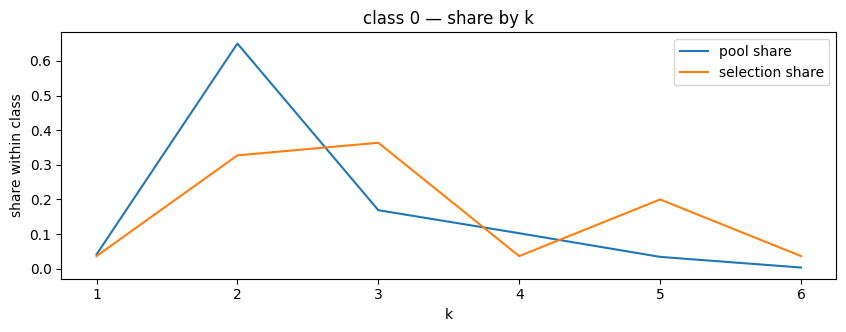

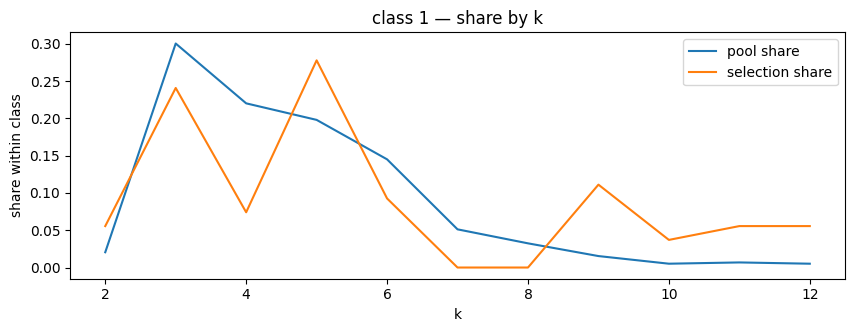

In [10]:
# builds summary tables
rep = selection_vs_pool_report(pool.bins_df, s.teaching_set_df)

print("Per-class, per-k comparison:")
display(
    rep["by_k"]
      .assign(selection_rate=lambda d: d["selection_rate"].round(3),
              lift=lambda d: d["lift"].round(3))
      .sort_values(["class_label", "k"])
      .reset_index(drop=True)
)

print("\nPer-class, per-k-bin comparison:")
display(
    rep["by_k_bin"]
      .assign(selection_rate=lambda d: d["selection_rate"].round(3),
              lift=lambda d: d["lift"].round(3))
      .sort_values(["class_label", "k_bin_label"])
      .reset_index(drop=True)
)

print("\nExtremes summary: (min/max k and rarest k per class in the pool)")
display(rep["extremes_summary"])

print("\nTeaching Pool share vs Teaching Set share")
for c in (0, 1):
    plot_df = rep["by_k"][rep["by_k"]["class_label"] == c]
    fig = plt.figure(figsize=(10, 3.2))
    ax = plt.gca()
    ax.plot(plot_df["k"], plot_df["share_in_class_pool"], label="pool share")
    ax.plot(plot_df["k"], plot_df["share_in_class_sel"], label="selection share")
    ax.set_title(f"class {c} — share by k")
    ax.set_xlabel("k")
    ax.set_ylabel("share within class")
    ax.legend()
    plt.show()


#### 4 - Serving examples from the teaching set
The user study has three trial groups. All groups sample from the same teaching set, i.e. the same charging session IDs. The nature and ordering of examples differ:

- **Group A** (explanations with curriculum): order by `k_power↑` then `margin_power↓`, overlay raw power with simplification and show simplified SOC. 
- **Group B** (explanations, no curriculum): random order, overlay raw power with simplification and show simplified SOC. 
- **Group C** (control, no explanations): random order, raw power and SOC only (no simplifications).

Constructing the teaching set is computationally expensive and the optimal teaching set for explaining the time series classifier (TSC) is large. 
We therefore cap the teaching set at most 100 per class by default to limit the computational effort required to build it. 

In [11]:
# builds group views from the selected set
df_A = s.sample_group_A(max_per_class=100)  # curriculum: k↑, margin↓
df_B = s.sample_group_B(max_per_class=100, seed=RANDOM_SEED)
df_C = s.sample_group_C(max_per_class=100, seed=RANDOM_SEED)

# verify same IDs across groups
ids_A = set(df_A["session_id"].unique().tolist())
ids_B = set(df_B["session_id"].unique().tolist())
ids_C = set(df_C["session_id"].unique().tolist())
print("ID sets identical across groups:", (ids_A == ids_B == ids_C))

# peek
display(df_A.head(1))

ID sets identical across groups: True


,session_id,class_label,k,k_bin_idx,k_bin_label,label_int,label_text,robust_prob,margin,threshold,...,piv_soc_path,model_id,gain_coverage,score_total,rank_in_bin,rank_in_class,k_bin,chosen_neighbors,group,show_simpl
2,12145955,0,1,0,"[1, 2]",0,normal,1.0,8.407482,8.5962,...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/1214...,final_model.pth,6.536997,7.427745,3,3,"[1, 2]","[12145955, 10229995, 2560674, 2361727, 9489647]",A,True


,session_id,group,k,label,sts_full_path,sts_soc_path,piv_path,piv_soc_path,raw_power_path,raw_soc_path
0,12145955,A,1,normal,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/121...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/1214...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/12145955...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/1214...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/12...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/1214...
1,2086667,A,2,abnormal,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/208...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/2086...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/2086667.npy,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/2086...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/20...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/2086...
2,9189528,A,1,normal,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/918...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/9189...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/9189528.npy,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/9189...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/91...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/9189...
3,3907158,A,2,abnormal,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/390...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/3907...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/3907158.npy,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/3907...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/39...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/3907...
4,9002133,A,2,normal,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_full/900...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/sts_soc/9002...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv/9002133.npy,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/piv_soc/9002...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_power/90...,/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Data/teaching_pool/raw_soc/9002...


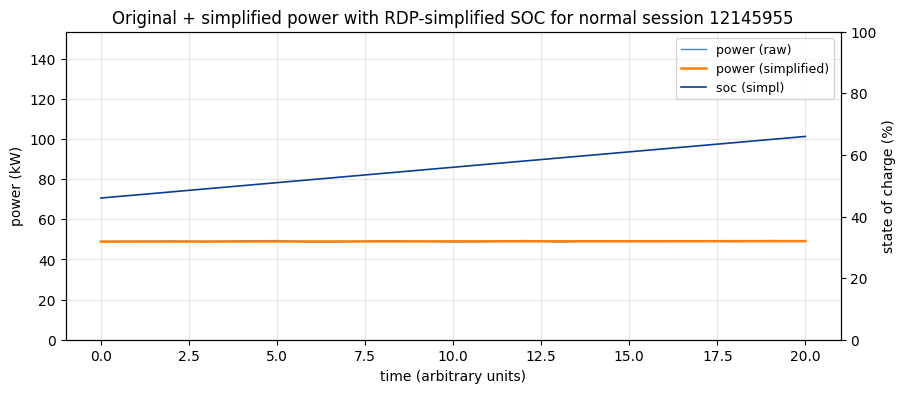

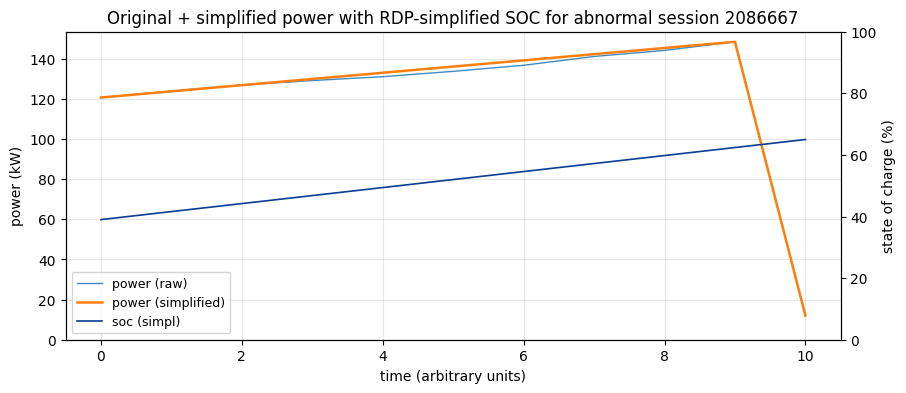

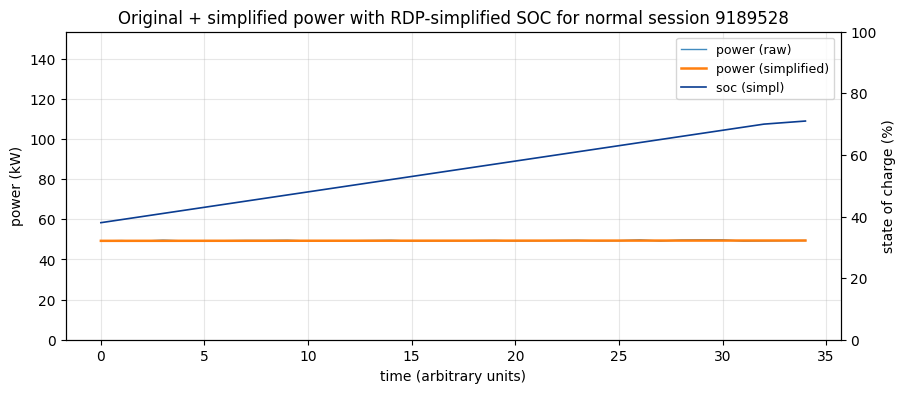

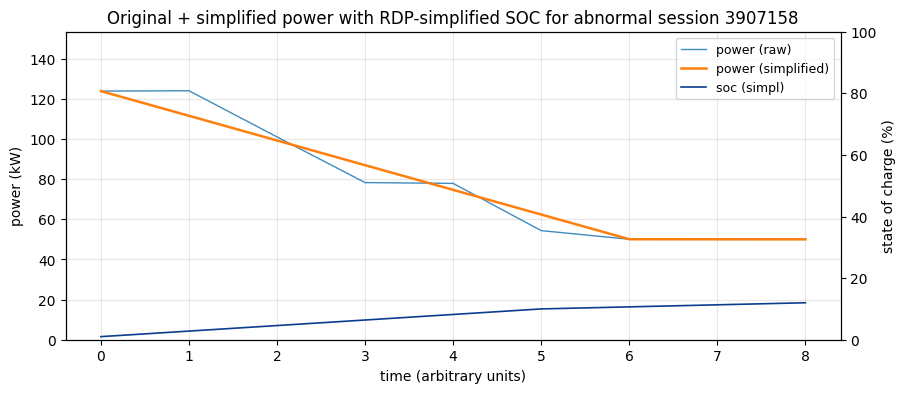

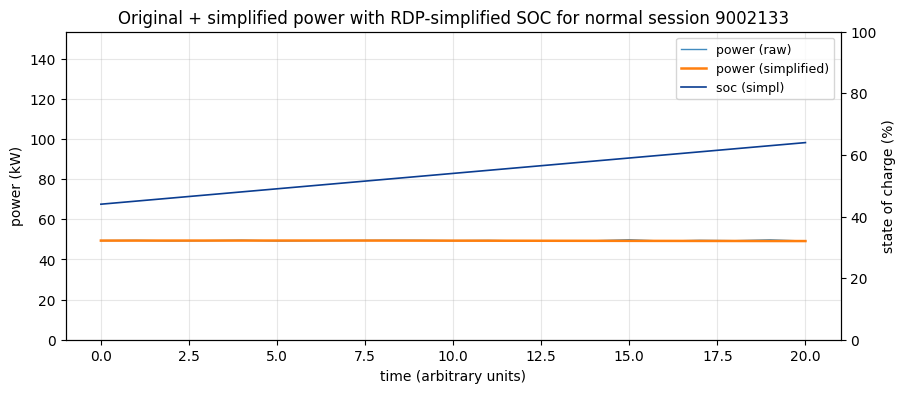

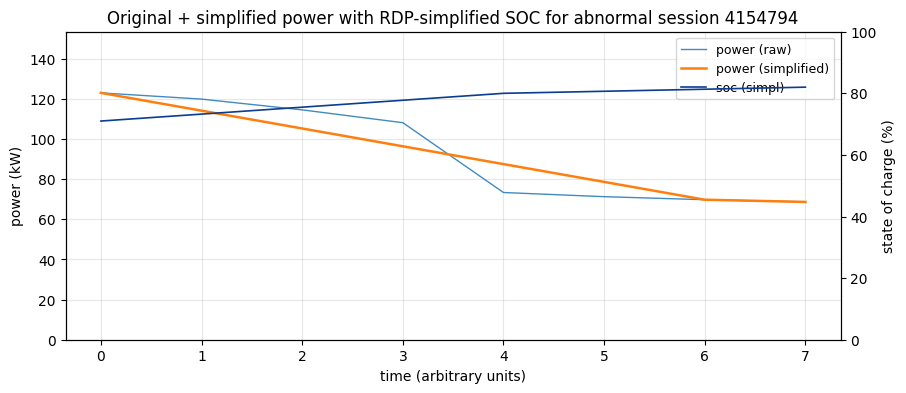

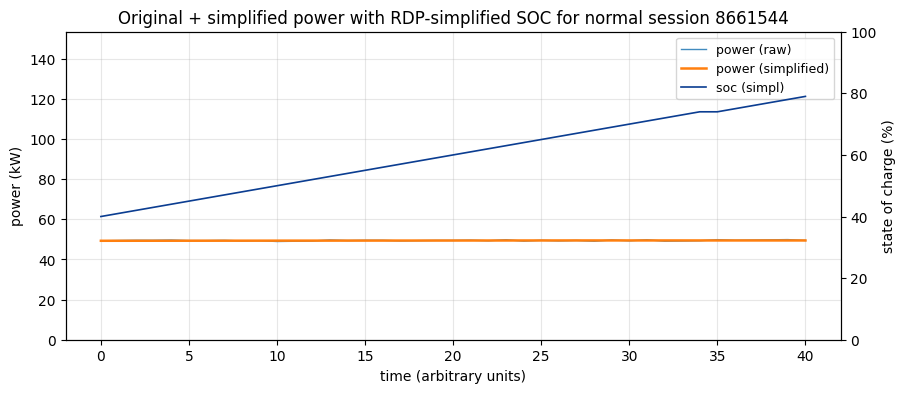

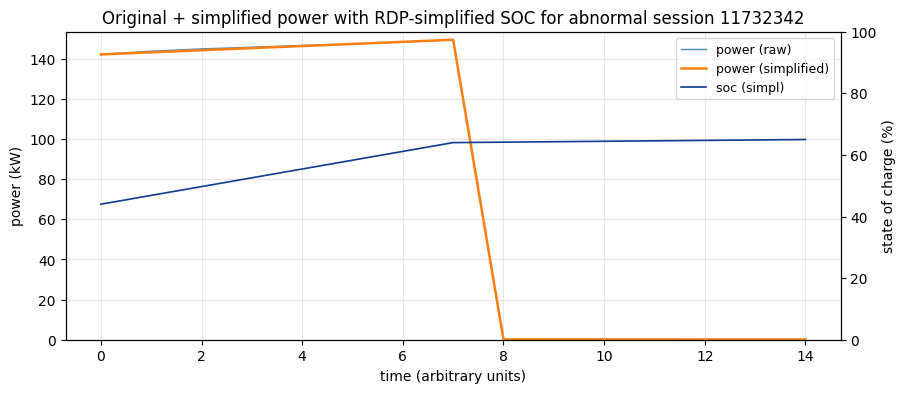

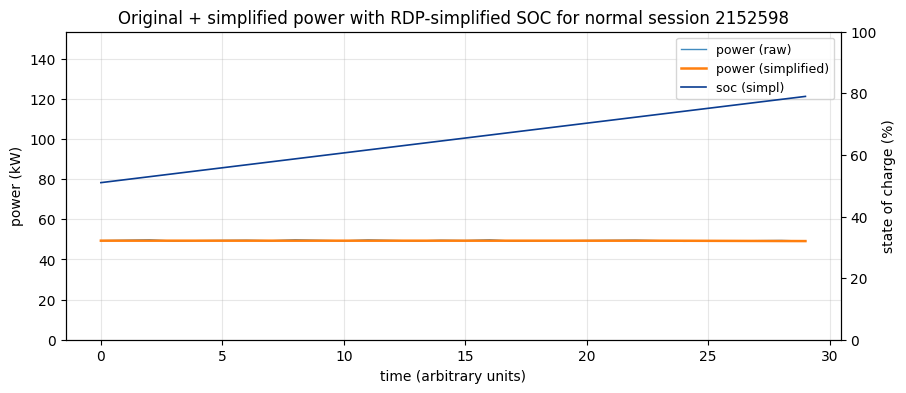

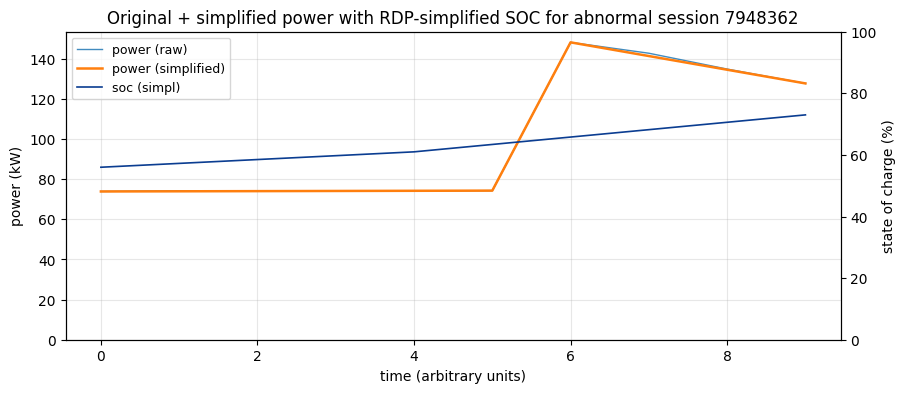

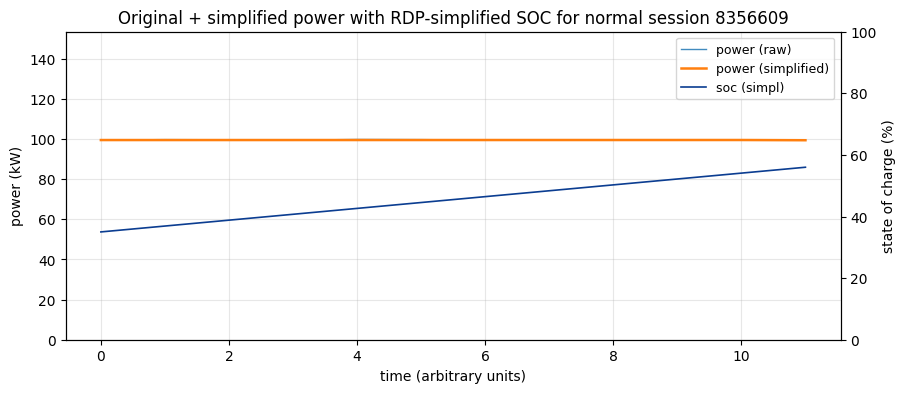

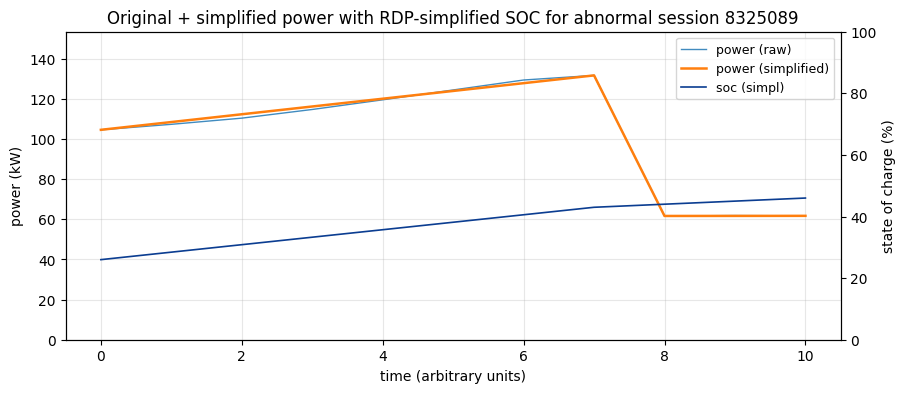

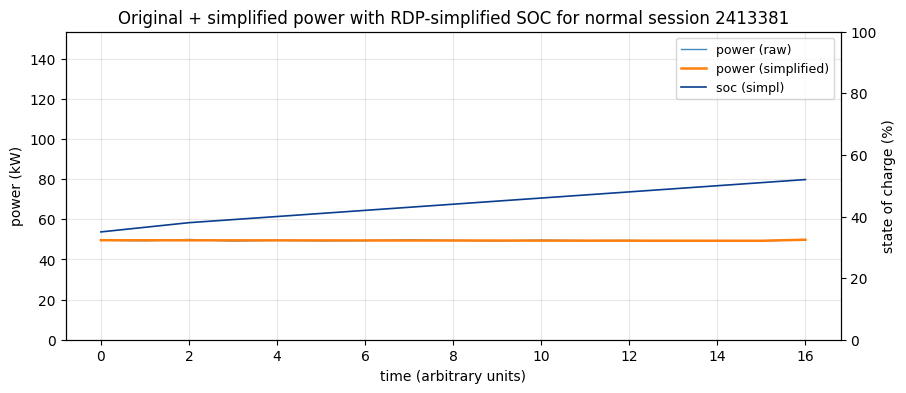

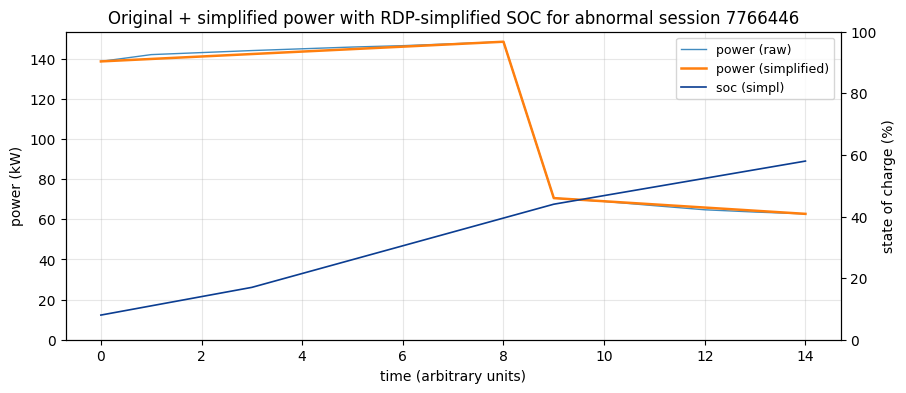

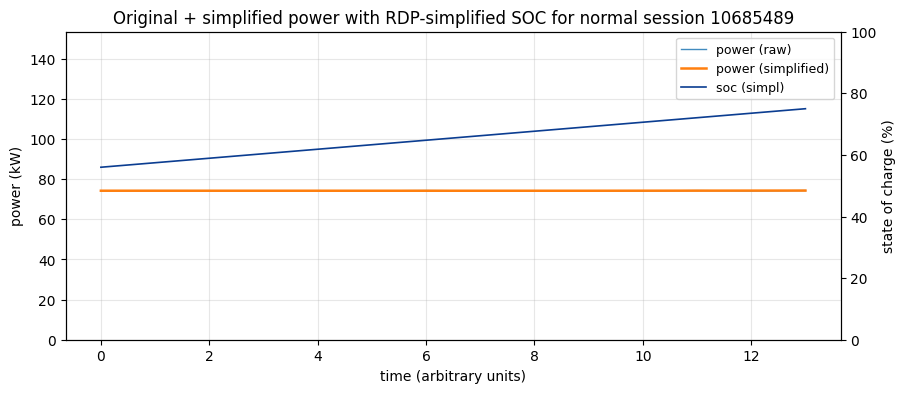

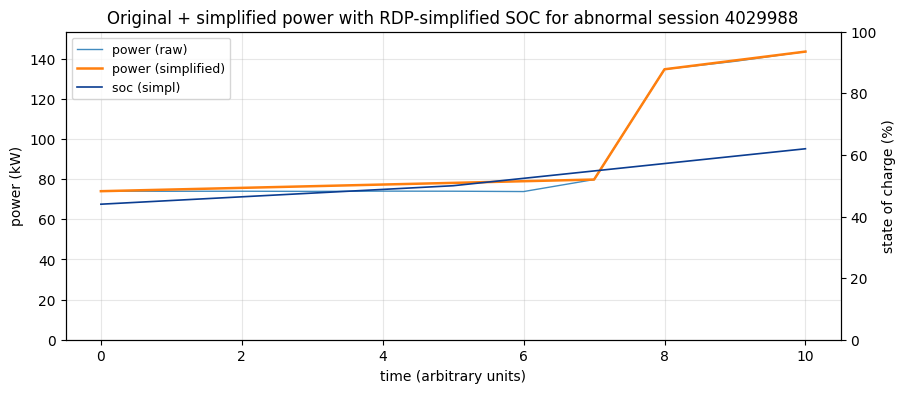

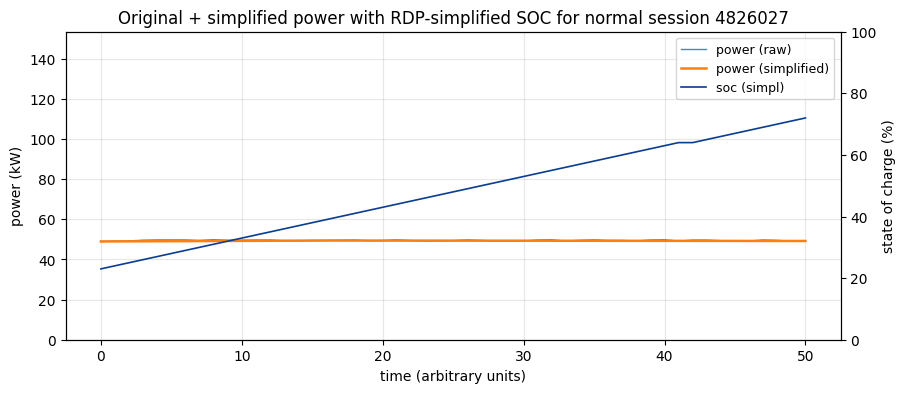

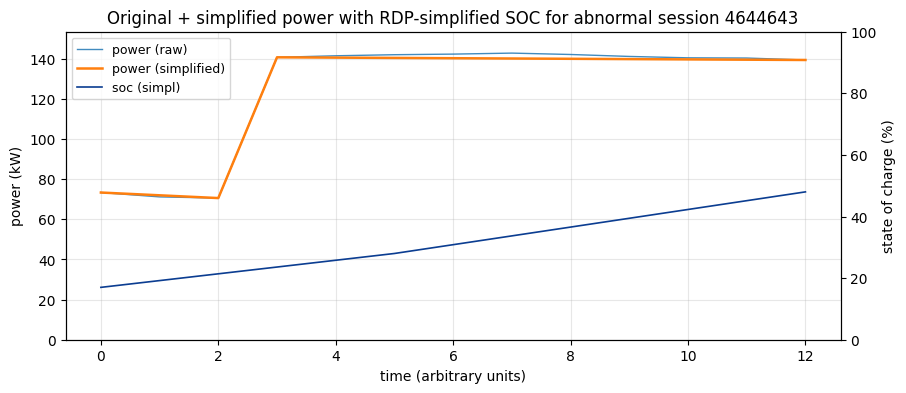

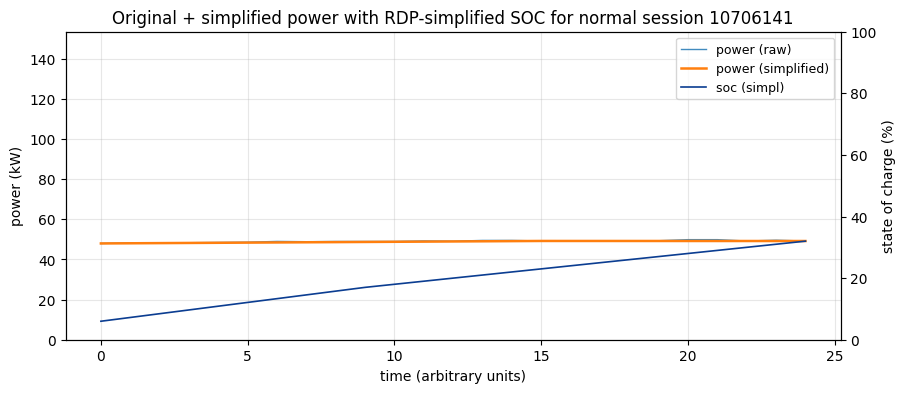

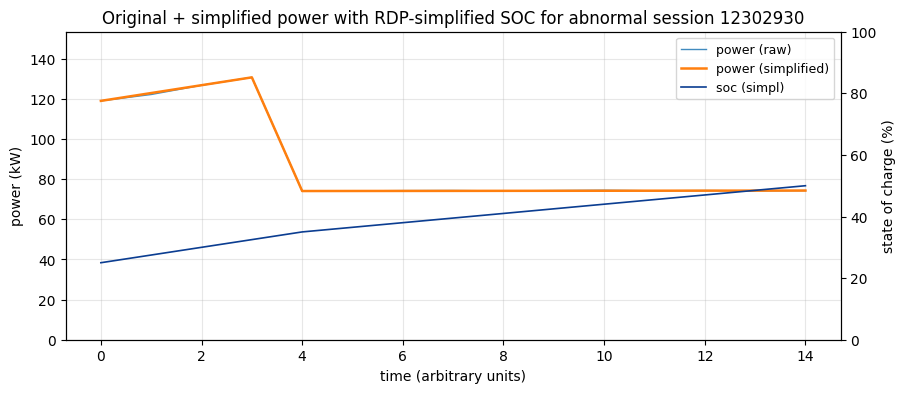

In [14]:
# build and attach iterators to the TeachingSet
iters = s.build_group_iterators(max_per_class=100, seed=RANDOM_SEED)

# demo: serve 6 examples per group and log metadata
logs = {"A": [], "B": [], "C": []}
# for g in ("A", "B", "C"):
for _ in range(20):
    try:
        meta = s.serve_sessions(group="A")  # plots immediately
        logs["A"].append(meta)
    except StopIteration:
        print(f"[{"A"}] no more examples.")
        break

pd.DataFrame(logs["A"]).head()
